# Milestone 3 — Outcome Validation

Strict-unsupervised honesty check: do discovered clusters align with the held-out CKD label?
Chi-squared independence test + cluster purity score.


In [1]:
import sys; sys.path.append('..')
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_theme(style='whitegrid')
FIGDIR = Path('../reports/figures')
DATA = Path('../data/processed')
MODELS = Path('../models')


## 1. Load clustered dataset

In [2]:
df = pd.read_csv(DATA / 'patients_clustered.csv')
print(df[['cluster_id', 'cluster_name', 'risk_tier', 'classification']].head())
print('Total:', len(df))


   cluster_id         cluster_name risk_tier  classification
0           0  Moderate Renal Risk    Medium               1
1           1    Stable / Low-Risk       Low               1
2           0  Moderate Renal Risk    Medium               1
3           0  Moderate Renal Risk    Medium               1
4           1    Stable / Low-Risk       Low               1
Total: 400


## 2. Contingency table + chi-squared

In [3]:
ct = pd.crosstab(df['cluster_id'], df['classification'])
print(ct)
chi2, p, dof, expected = stats.chi2_contingency(ct)
print(f'Chi-squared = {chi2:.2f}, dof = {dof}, p = {p:.4g}')


classification    0    1
cluster_id              
0                 0  120
1               150   58
2                 0   72
Chi-squared = 221.54, dof = 2, p = 7.826e-49


## 3. Purity score

In [4]:
purity = ct.max(axis=1).sum() / ct.values.sum()
print(f'Cluster purity vs CKD label: {purity:.3f}')


Cluster purity vs CKD label: 0.855


## 4. Cluster x CKD heatmap

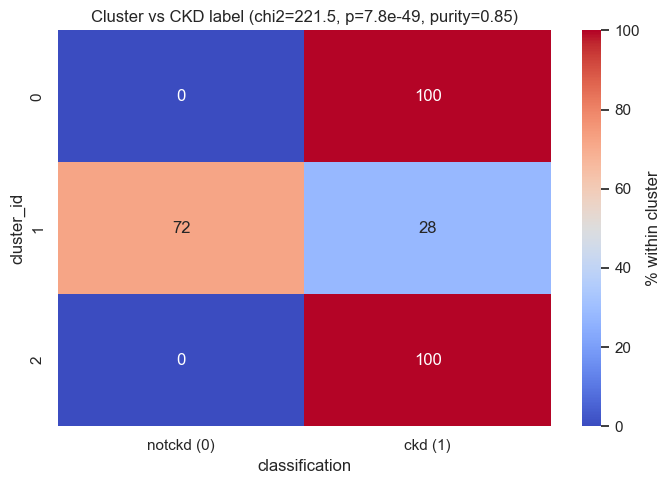

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
sns.heatmap(ct_pct, annot=True, fmt='.0f', cmap='coolwarm', ax=ax, cbar_kws={'label': '% within cluster'})
ax.set_xticklabels(['notckd (0)', 'ckd (1)'])
ax.set_title(f'Cluster vs CKD label (chi2={chi2:.1f}, p={p:.2g}, purity={purity:.2f})')
plt.tight_layout()
plt.savefig(FIGDIR / 'cluster_vs_ckd.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Save validation summary

In [6]:
validation = {
    'chi2': float(chi2),
    'dof': int(dof),
    'p_value': float(p),
    'purity': float(purity),
    'contingency': ct.to_dict(),
}
with open(MODELS / 'outcome_validation.json', 'w') as f:
    json.dump(validation, f, indent=2, default=str)
print('Saved outcome_validation.json')


Saved outcome_validation.json
